# Geometry effect

How sensitive each algorithm is to city geometry (symmetric vs asymmetric
demand). For every metric the delta imbalanced - balanced is computed, matched
per (d, R, behaviour, initial_conditions). A delta near zero means the
algorithm is robust to geometry, a large one means it amplifies or absorbs
spatial imbalance. Plots: delta vs R per metric, an algorithm x metric
sensitivity heatmap, winner and loser bars for service rate and safety, and
regional heatmaps of one chosen algorithm in both geometries.

No GEOMETRY toggle here, comparing the two layouts is the point. Sections 1-4
use summary data, Section 5 loads the regional per-request cache.

`d` is the average distance between taxis, so larger d means fewer taxis.


In [2]:
from pathlib import Path

# Algorithm to drill into for the Section 5 regional heatmaps.
REGIONAL_EXP = 'exp1'          # any experiment id present in both geometries
REGIONAL_R = 0.5
REGIONAL_BEHAVIOUR = 'go_back'
REGIONAL_IC = 'home'           # only the median-d (258) run is cached

CACHE_DIR = Path('.') / 'cache'
FORCE_RECOMPUTE = False

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from exp_utils import (GROUP_CONFIGS, load_experiment_set, match_run_pairs,
                       load_regions, aggregate_region_stats, compute_regional_gini,
                       plot_region_heatmap, fmt_display, exp_label, apply_pub_style,
                       METRIC_RANGE)

apply_pub_style()

## 1. Load both geometries and build cross-geometry deltas

For each algorithm, inner-join the balanced and imbalanced runs on
(d, R, behaviour, ic) and take `imbalanced - balanced` for every metric.

In [ ]:
bal = load_experiment_set('balanced', cache_dir=CACHE_DIR, force=FORCE_RECOMPUTE)
imb = load_experiment_set('imbalanced', cache_dir=CACHE_DIR, force=FORCE_RECOMPUTE)
if bal.empty or imb.empty:
    raise RuntimeError('Need both geometries cached. Run cache_all.py first.')

EXPERIMENTS = sorted(set(bal['experiment']) & set(imb['experiment']))
EXP_ALGO = bal.drop_duplicates('experiment').set_index('experiment')['algorithm'].to_dict()
EXP_LABEL = {e: exp_label(e, EXP_ALGO[e]) for e in EXPERIMENTS}
_cmap = plt.get_cmap('tab10')
EXP_COLOR = {e: _cmap(i % 10) for i, e in enumerate(EXPERIMENTS)}

R_vals = sorted(bal['R'].dropna().unique())
KEYS = ['d', 'R', 'behaviour', 'initial_conditions']

DELTA_METRICS = [
    ('service_rate',            'Service rate',          '{:+.3f}'),
    ('final_safety_mean',       'Driver safety',         '{:+.2f}'),
    ('final_satisfaction_mean', 'Satisfaction',          '{:+.2f}'),
    ('wait_to_pickup_mean',     'Wait to pickup (TU)',   '{:+.0f}'),
    ('income_gini',             'Income Gini',           '{:+.3f}'),
    ('final_income_mean',       'Income',                '{:+.1f}'),
]
DELTA_METRICS = [(c, l, f) for c, l, f in DELTA_METRICS
                 if c in bal.columns and c in imb.columns]
DELTA_COLS = [c for c, _, _ in DELTA_METRICS]


def geometry_deltas(exp):
    b = bal[bal['experiment'] == exp]
    m = match_run_pairs(b, imb[imb['experiment'] == exp], keys=KEYS)
    out = m[KEYS].copy()
    for col in DELTA_COLS:
        a, c = f'{col}_exp1', f'{col}_exp2'      # _exp1 = balanced, _exp2 = imbalanced
        if a in m.columns and c in m.columns:
            out[col] = m[c] - m[a]
    out['experiment'] = exp
    return out


deltas = {e: geometry_deltas(e) for e in EXPERIMENTS}
print('Experiments:', [EXP_LABEL[e] for e in EXPERIMENTS])
print('matched pairs (imb inner-join bal):', {e: len(v) for e, v in deltas.items()})

## 2. Geometry sensitivity overview

For each metric, the cross geometry delta vs R, one line per algorithm. Lines
near zero mean the algorithm is robust to geometry. Each point averages the per
run delta over d / behaviour / ic. Error bars show the spread across d.


In [ ]:
ncols = 3
nrows = int(np.ceil(len(DELTA_METRICS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.8 * ncols, 3.3 * nrows))
axes = np.atleast_1d(axes).reshape(-1)
handles = labels = None
for ax, (col, label, _f) in zip(axes, DELTA_METRICS):
    for e in EXPERIMENTS:
        d = deltas[e]
        per_d = d.groupby(['R', 'd'])[col].mean().reset_index()
        gmean = per_d.groupby('R')[col].mean().reindex(R_vals)
        gstd = per_d.groupby('R')[col].std().reindex(R_vals)
        ax.errorbar(R_vals, gmean.values, yerr=gstd.values, fmt='o-',
                    color=EXP_COLOR[e], label=EXP_LABEL[e], capsize=3,
                    linewidth=1.6, markersize=5)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Demand ratio R')
    ax.set_ylabel(f'delta {label}')
    ax.set_title(label)
    ax.set_xticks(R_vals)
    if handles is None:
        handles, labels = ax.get_legend_handles_labels()
for ax in axes[len(DELTA_METRICS):]:
    ax.axis('off')
# Wrap the 7-algorithm legend onto two rows so it stays compact and the panels
# can use more of the figure width/height.
legend_ncol = int(np.ceil(len(EXPERIMENTS) / 2))
fig.legend(handles, labels, loc='lower center', ncol=legend_ncol,
           fontsize=12, frameon=False, bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

## 3. Algorithm x metric sensitivity heatmap

Mean cross geometry delta across all (d, R) for each algorithm and metric.
Colour is normalised per column (each metric scaled by its own max absolute
delta) so columns with different units are comparable. The annotation is the
raw delta. Blue = higher under imbalanced, red = lower.


In [ ]:
mat = pd.DataFrame(
    {col: [deltas[e][col].mean() for e in EXPERIMENTS] for col in DELTA_COLS},
    index=EXPERIMENTS,
)
norm = mat.copy()
for col in DELTA_COLS:
    mx = np.nanmax(np.abs(mat[col].values))
    norm[col] = mat[col] / mx if mx and np.isfinite(mx) else 0.0

fig, ax = plt.subplots(figsize=(1.4 * len(DELTA_COLS) + 3, 0.55 * len(EXPERIMENTS) + 2))
im = ax.imshow(norm.values, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(DELTA_COLS)))
ax.set_xticklabels([l for _, l, _ in DELTA_METRICS], rotation=25, ha='right', fontsize=12)
ax.set_yticks(range(len(EXPERIMENTS)))
ax.set_yticklabels([EXP_LABEL[e] for e in EXPERIMENTS], fontsize=12)
ax.grid(False)
fmt_by_col = {c: f for c, _, f in DELTA_METRICS}
for i, e in enumerate(EXPERIMENTS):
    for j, col in enumerate(DELTA_COLS):
        v = mat.loc[e, col]
        if np.isfinite(v):
            ax.text(j, i, fmt_by_col[col].format(v), ha='center', va='center',
                    fontsize=12, color='black')
plt.colorbar(im, ax=ax, shrink=0.8, label='per-column normalised delta')
ax.set_title('Mean delta (imbalanced - balanced) by algorithm x metric')
plt.tight_layout()
plt.show()

## 4. Who benefits, who loses

Cross-geometry delta for service rate and driver safety, one bar per algorithm at
each R. Bars below zero = the asymmetric city hurts that metric for that algorithm.

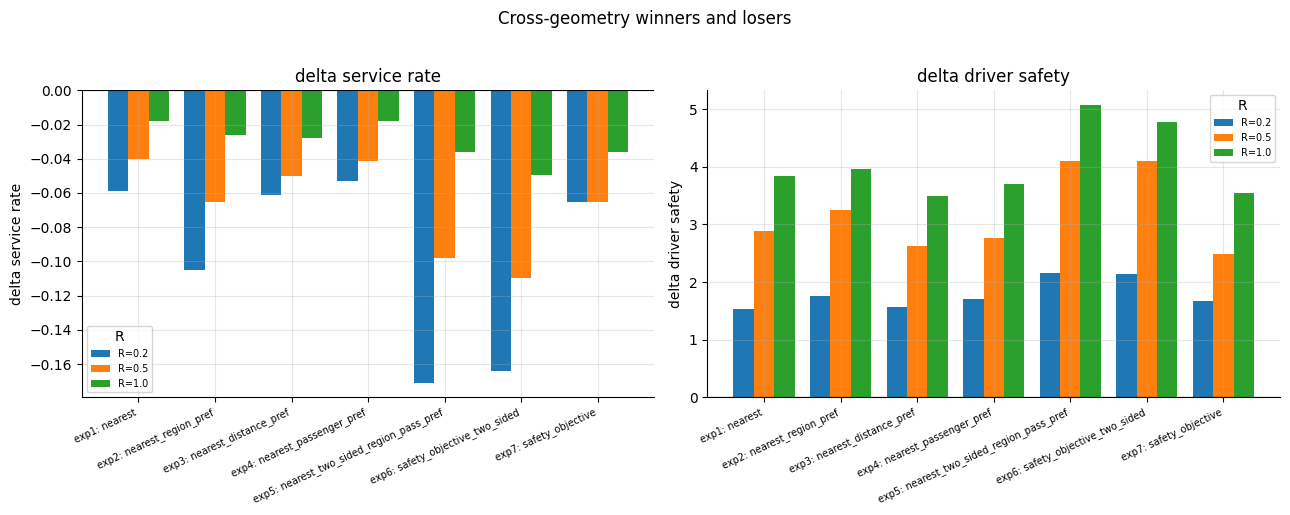

In [7]:
who_metrics = [m for m in [('service_rate', 'delta service rate'),
                           ('final_safety_mean', 'delta driver safety')]
               if m[0] in DELTA_COLS]
fig, axes = plt.subplots(1, len(who_metrics), figsize=(6.5 * len(who_metrics), 5))
axes = np.atleast_1d(axes)
x = np.arange(len(EXPERIMENTS))
w = 0.8 / max(len(R_vals), 1)
for ax, (col, label) in zip(axes, who_metrics):
    for i, r in enumerate(R_vals):
        vals = [deltas[e][deltas[e]['R'] == r][col].mean() for e in EXPERIMENTS]
        ax.bar(x + i * w, vals, w, label=f'R={r}')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x + w * (len(R_vals) - 1) / 2)
    ax.set_xticklabels([EXP_LABEL[e] for e in EXPERIMENTS], rotation=25,
                       ha='right', fontsize=12)
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.legend(title='R', fontsize=12)
fig.suptitle('Cross-geometry winners and losers', y=1.02)
plt.tight_layout()
plt.show()

## 5. Regional heatmaps side-by-side (one algorithm)

Balanced vs imbalanced spatial pattern for the selected algorithm at a single
operating point. Shows where the imbalance manifests. Only the median-d (258) run
is cached, so REGIONAL_D is fixed to 258.

In [ ]:
def _pick(reg, R, beh, ic):
    for rid, (row, req) in reg.items():
        if (row.get('R') == R and row.get('behaviour') == beh
                and row.get('initial_conditions') == ic):
            return rid, row, req
    return None


# non_completion_rate (not drop_rate): comparable across algorithms because the
# nearest baseline drops unserved requests while the preference algorithms leave
# them pending.
# All columns use the same colormap orientation (viridis: bright = high value) so a
# given colour means the same magnitude everywhere; read the column label for
# whether a high value is good (safety) or bad (wait, non-completion). Mixing
# viridis/viridis_r per metric reads as confusing photo-negatives across columns
# (same convention as regional_fairness_across_algorithms.ipynb).
REG_METRICS = [
    ('mean_wait_to_pickup', 'wait_to_pickup', 'Mean wait to pickup', 'viridis'),
    ('mean_driver_safety_score_pickup', 'driver_safety_score_pickup',
     'Driver safety at pickup', 'viridis'),
    ('non_completion_rate', None, 'Non-completion rate', 'viridis'),
]

import pickle
loaded = {}
for geom in ('balanced', 'imbalanced'):
    group = f'{REGIONAL_EXP}_{geom}'
    cfg = GROUP_CONFIGS.get(group)
    cache_file = CACHE_DIR / f'{group}_regional.pkl'
    if cfg is None or not cache_file.exists():
        print(f'  [skip] {group}: regional cache not found')
        continue
    with open(cache_file, 'rb') as f:
        reg = pickle.load(f)
    hit = _pick(reg, REGIONAL_R, REGIONAL_BEHAVIOUR, REGIONAL_IC)
    if hit is None:
        print(f'  [skip] {group}: no run R={REGIONAL_R} {REGIONAL_BEHAVIOUR}/{REGIONAL_IC}')
        continue
    rid, row, req = hit
    regions_cfg = load_regions(cfg['regions_file'])
    regions = regions_cfg.get('regions', regions_cfg)
    metric_cols = [m[1] for m in REG_METRICS if m[1] is not None]
    stats = aggregate_region_stats(req, regions, 'origin_region', metric_cols)
    loaded[geom] = (regions_cfg, stats)
    print(f'  {group}: {len(req)} requests, run d={row.get("d")}')

if len(loaded) < 1:
    print('No regional data loaded for', REGIONAL_EXP)
else:
    geoms = list(loaded.items())
    nrow = len(geoms)
    ncol = len(REG_METRICS)
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.4 * ncol, 3.2 * nrow),
                             constrained_layout=True)
    axes = np.array(axes).reshape(nrow, ncol)
    # Geometries down the rows, the three metrics across the columns (landscape, so
    # it uses less page height). Colour maps anchored to each metric's natural full
    # range (METRIC_RANGE) with one shared colorbar per metric column; per-cell
    # value labels make the absolute numbers readable (counts suppressed). The
    # imbalanced layout has small uneven corner regions, so the in-cell text is set
    # small (label_fontsize) to stop the region name + value overflowing the box.
    for c, (mcol, _src, mlabel, cmap) in enumerate(REG_METRICS):
        rng = METRIC_RANGE.get(mcol)
        if rng is not None:
            vmin, vmax = rng
        else:
            vals = [s[mcol].dropna() for (_c, s) in loaded.values() if mcol in s.columns]
            allv = pd.concat(vals) if vals else pd.Series(dtype=float)
            vmin = float(allv.min()) if not allv.empty else 0.0
            vmax = float(allv.max()) if not allv.empty else 1.0
        for r, (geom, (rcfg, stats)) in enumerate(geoms):
            ax = axes[r, c]
            title = mlabel if r == 0 else ''
            if mcol in stats.columns:
                plot_region_heatmap(ax, stats, mcol, rcfg, title=title,
                                    cmap=cmap, vmin=vmin, vmax=vmax,
                                    show_labels=True, show_count=False,
                                    label_fontsize=7,
                                    colorbar=False, square=False)
            else:
                ax.set_title(title if title else f'{geom} (n/a)')
                ax.axis('off')
            if c == 0:
                ax.set_ylabel(geom)
        sm = plt.cm.ScalarMappable(cmap=plt.get_cmap(cmap), norm=plt.Normalize(vmin, vmax))
        sm.set_array([])
        fig.colorbar(sm, ax=list(axes[:, c]), location='bottom',
                     fraction=0.046, pad=0.02, aspect=18)
    fig.suptitle(f'{EXP_LABEL.get(REGIONAL_EXP, REGIONAL_EXP)}  '
                 f'(R={REGIONAL_R}, {REGIONAL_BEHAVIOUR}, d=258)')
    plt.show()

## Significance

The same sweep and replicate tests as the other cross-experiment notebooks (see
`guides/STATISTICAL_ANALYSIS_PLAN.md`), used here as a within-algorithm
comparison: balanced vs imbalanced runs paired by (d, R, behaviour, ic) via
`group_col='geometry'`. Positive delta = balanced higher. Holm correction
within each metric. Gini is compared by Mann-Whitney, never a t-test.


In [9]:
from exp_utils import significance_summary, FOCUS_SETUP

# Geometry effect is a WITHIN-algorithm comparison: balanced vs imbalanced paired by
# (d,R,behaviour,ic). group_col='geometry' selects the two sides; positive delta =
# balanced higher. Run per algorithm and stack.
bal_reps = load_experiment_set('balanced', cache_dir=CACHE_DIR, include_reps=True,
                               force=FORCE_RECOMPUTE)
imb_reps = load_experiment_set('imbalanced', cache_dir=CACHE_DIR, include_reps=True,
                               force=FORCE_RECOMPUTE)
grid_both = pd.concat([bal, imb], ignore_index=True)
reps_both = pd.concat([bal_reps, imb_reps], ignore_index=True)

SIG_METRICS = [m for m in ['final_safety_mean', 'service_rate', 'income_gini']
               if m in grid_both.columns]
parts = []
for e in EXPERIMENTS:
    s = significance_summary(
        grid_both[grid_both['experiment'] == e],
        reps_both[reps_both['experiment'] == e],
        [('balanced', 'imbalanced')], SIG_METRICS,
        setup=FOCUS_SETUP, group_col='geometry')
    if not s.empty:
        s.insert(0, 'experiment', e)
        parts.append(s)
sig = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
SIG_SHOW = ['experiment', 'metric', 'sweep_n', 'sweep_p_adj', 'sweep_cliff', 'sweep_mag',
            'sweep_signs', 'foc_diff', 'foc_ci_lo', 'foc_ci_hi', 'foc_welch_p',
            'foc_mw_p', 'foc_p_adj', 'foc_cohens_d']
SIG_FMT = {'sweep_p_adj': '{:.2g}', 'sweep_cliff': '{:+.2f}', 'foc_diff': '{:+.3f}',
           'foc_ci_lo': '{:+.3f}', 'foc_ci_hi': '{:+.3f}', 'foc_welch_p': '{:.2g}',
           'foc_mw_p': '{:.2g}', 'foc_p_adj': '{:.2g}', 'foc_cohens_d': '{:+.2f}'}
SIG_SHOW = [c for c in SIG_SHOW if c in sig.columns]
display(fmt_display(sig[SIG_SHOW], fmt=SIG_FMT) if not sig.empty else sig)

[cache HIT]  exp1_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp2_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp3_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp4_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp5_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp6_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp7_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp1_imbalanced_summary.pkl  ->  loading summary
[cache HIT]  exp2_imbalanced_summary.pkl  ->  loading summary
[cache HIT]  exp3_imbalanced_summary.pkl  ->  loading summary
[cache HIT]  exp4_imbalanced_summary.pkl  ->  loading summary
[cache HIT]  exp5_imbalanced_summary.pkl  ->  loading summary
[cache HIT]  exp6_imbalanced_summary.pkl  ->  loading summary
[cache HIT]  exp7_imbalanced_summary.pkl  ->  loading summary


,experiment,metric,sweep_n,sweep_p_adj,sweep_cliff,sweep_mag,sweep_signs,foc_diff,foc_ci_lo,foc_ci_hi,foc_welch_p,foc_mw_p,foc_p_adj,foc_cohens_d
0,exp1,final_safety_mean,60,1.6e-11,-0.52,large,60/60 a<b,-2.385,-2.655,-2.115,6.6e-14,8.2e-05,6.6e-14,-7.87
1,exp1,service_rate,60,6e-11,+0.28,small,59/60 a>b,+0.082,+0.079,+0.085,6.8e-19,8.2e-05,6.8e-19,+24.31
2,exp1,income_gini,60,3.1e-07,-0.51,large,45/60 a<b,-0.125,-0.130,-0.119,-,8.2e-05,8.2e-05,-
3,exp2,final_safety_mean,60,1.6e-11,-0.53,large,60/60 a<b,-3.564,-3.863,-3.265,1.7e-16,8.2e-05,1.7e-16,-10.61
4,exp2,service_rate,60,1.6e-11,+0.32,small,60/60 a>b,+0.115,+0.112,+0.119,4.5e-18,8.2e-05,4.5e-18,+32.44
5,exp2,income_gini,60,4.2e-09,-0.55,large,51/60 a<b,-0.157,-0.162,-0.152,-,8.2e-05,8.2e-05,-
6,exp3,final_safety_mean,60,1.6e-11,-0.53,large,60/60 a<b,-2.425,-2.683,-2.168,3.1e-14,8.2e-05,3.1e-14,-8.41
7,exp3,service_rate,60,1.2e-10,+0.30,small,56/60 a>b,+0.096,+0.093,+0.098,5.5e-18,8.2e-05,5.5e-18,+30.59
8,exp3,income_gini,60,1.4e-10,-0.63,large,56/60 a<b,-0.128,-0.133,-0.124,-,8.2e-05,8.2e-05,-
9,exp4,final_safety_mean,60,1.7e-11,-0.53,large,59/60 a<b,-2.813,-3.033,-2.594,3.5e-16,8.2e-05,3.5e-16,-11.46
